## UMAP embedding visualization

We produce a UMAP visualization of the embeddings of the `[CLS]` tokens.

In [9]:
import numpy as np, umap

# names of datasets for labels
ds_names = ['qqp', 'qnli', 'wiki', 'books']
# take only a sample from the datasets
n = 16000
# seeded rng
rng = np.random.default_rng(1)

We have now finished setting up.

In [ ]:
# examples and example labels
# will collect here, across datasets
X, Y = [], []

for idx, ds in enumerate(ds_names):
    # mmap for speed, remove this parameter if not enough space in memory
    embed = np.load(f'../../../embeds/full/{ds}_embed.npy', mmap_mode='r')
    # get a sample of n dataset items (as indices)
    sample = rng.choice(embed.shape[0], n, replace=False)
    # append embeds for the indices in sample to X
    X.append(np.array(embed[sample]))
    # append 0/1/2/3 repeated enough times to Y
    Y.append(np.full(n, idx))

# take shapes from (4, 16000, 768) to (64000, 768)
X = np.concat(X)
Y = np.concat(Y)

# instantiate the umap reducer
# we'll get a warning because we can't both parallelize and use a seed
# however, we're not using multiple processes to do this anyway
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=1)
# get the projection
Z = reducer.fit_transform(X)

/home/mihnea/Desktop/blackbox-re26/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


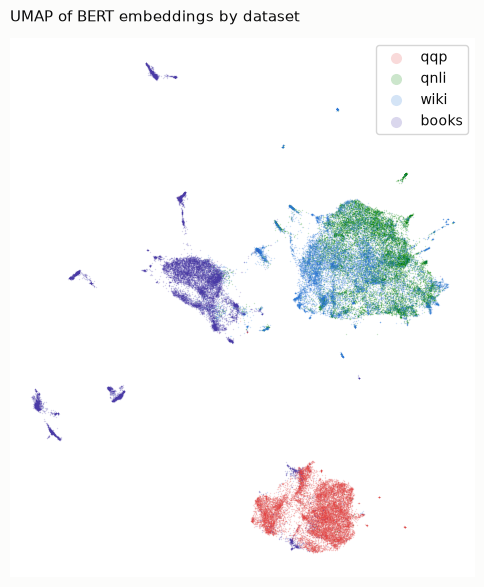

In [32]:
import matplotlib.pyplot as plt

colors = ['#e34948',    # qqp
          '#008300',    # qnli
          '#2a78d6',    # wiki
          '#4a3aa7']    # books

# chart surface and text ink
bg = '#fcfcfb'

# make the plot
fig, ax = plt.subplots(figsize=(6, 7), facecolor=bg)

# we plot dataset individually
for idx, (label, color) in enumerate(zip(ds_names, colors)):
    # obtain a mask for each dataset index 0/1/2/3
    mask = (Y == idx)
    # plot the dataset
    ax.scatter(Z[mask, 0], Z[mask, 1], 
               s=1, c=color, alpha=0.2, linewidths=0, label=label)

# UMAP coordinates are meaningless, no reason to plot them
# accordingly, remove all the ticks from the graph
ax.set_xticks([])
ax.set_yticks([])

# also remove all the spines from the graph
for spine in ax.spines.values(): 
    spine.set_visible(False)

# legend on the right-hand corner of the graph
ax.legend(markerscale=8, loc='upper right', labelcolor='#0b0b0b')


ax.set_title('UMAP of BERT embeddings by dataset',
             color='#0b0b0b', 
             fontsize=11, 
             loc='left', 
             pad=12)

# show the plot
plt.show()
